# Student Success Analytics & Predictive Modeling
## Author : Yazan Maghary 
## Date : 06/05/2026
## Data_Source : Online School Learning Management System (LMS)
Understand student demographics through segmentation and predict course completion using high-dimensional engagement logs.
The project combines Unsupervised KMeans clustering and an iterative Keras Sequential Deep Learning model optimized with PCA.
Target variable: `passed_course` (Binary).

> Table of Contents : 
1. [Importing Libraries And Functions](#Importing-Libraries-And-Functions)
2. [Part 2: Data Loading and Cleaning for Modeling](#Part-1:-Data-Loading-and-EDA-for-Clustering)
5. [Part 2: High-Dimensional Data Processing & PCA](#Part-2:-High-Dimensional-Data-Processing-&-PCA)
6. [Part 2: Iterative Deep Learning Model Build](#Part-2:-Iterative-Deep-Learning-Model-Build)
7. [Part 2: Final Model Evaluation & Business Insights](#Part-2:-Final-Model-Evaluation-&-Business-Insights)

# Importing Libraries And Functions

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
# impot pca 
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score 
import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras import metrics
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping 
from tensorflow.keras.layers import Dense, Dropout

## Custom Functions

In [2]:
# Custom function for plotting each metric
def plot_history(history, figsize=(6,12), marker='o'):
       
    # Get list of metrics from history
    metrics = [c for c in history.history if not c.startswith('val_')]
    
    ## Separate row for each metric
    fig, axes = plt.subplots(nrows=len(metrics),figsize=figsize)
    
    # For each metric
    for i, metric_name in enumerate(metrics):
    
        # Get the axis for the current metric
        ax = axes[i]
    
        # Get metric from history.history
        metric_values = history.history[metric_name]
        # Get epochs from history
        epochs = history.epoch
    
        # Plot the training metric
        ax.plot(epochs, metric_values, label=metric_name, marker=marker)
    
        ## Check if val_{metric} exists. if so, plot:
        val_metric_name = f"val_{metric_name}"
        if val_metric_name in history.history:
            # Get validation values and plot
            metric_values = history.history[val_metric_name]
            ax.plot(epochs,metric_values,label=val_metric_name, marker=marker)
    
        # Final subplot adjustments 
        ax.legend()
        ax.set_title(metric_name)
    fig.tight_layout()

    return fig, axes

In [3]:
# import 
from sklearn.metrics import accuracy_score , confusion_matrix , ConfusionMatrixDisplay ,classification_report

def classification_metrics(y_true , y_pred , target_names ,label='', output_dict = False , fig_size = (8,4) , normalize = 'true' , cmap='Blues' , colorbar = False):
    report = classification_report(y_true , y_pred ,target_names=target_names)
    header = '-'*70
    print(header ,f"Classification metrics : {label}" , header ,sep="\n")
    print(report)
    fig ,axes = plt.subplots(figsize=fig_size , ncols=2)
    ConfusionMatrixDisplay.from_predictions(y_true , y_pred ,cmap='gist_gray',normalize=None , colorbar=colorbar ,ax=axes[0],display_labels=target_names)
    axes[0].set_title("Confusion Matrix")
     
    ConfusionMatrixDisplay.from_predictions(y_true , y_pred ,cmap=cmap ,normalize=normalize , colorbar=colorbar ,ax=axes[1],display_labels=target_names)
    axes[1].set_title("Normalized Confusion Matrix")
    fig.tight_layout()
    plt.show()
    if output_dict == True :
        report_dict = classification_report(y_true , y_pred ,output_dict=output_dict,target_names=target_names)
        return report_dict
    
def evaluation_classification(model , X_train , y_train , X_test , y_test , target_names ,figsize = (6,4) , normalize= 'true' , output_dict = False , cmap_train = 'Blues' , cmap_test = 'Reds' , colorbar = False):
    y_train_pred = model.predict(X_train)
    y_train_pred = np.where(y_train_pred > 0.5 , 1 , 0)
    result_train = classification_metrics(y_train , y_train_pred ,output_dict=output_dict , fig_size=figsize , cmap=cmap_train , normalize=normalize , colorbar=colorbar ,label='Training Data' ,target_names=target_names)
    print()
    y_test_pred = model.predict(X_test)
    y_test_pred = np.where(y_test_pred > 0.5 , 1 , 0)
    result_test = classification_metrics(y_test ,y_test_pred ,output_dict=output_dict , fig_size=figsize , cmap=cmap_train , normalize=normalize , colorbar=colorbar ,label='Testing Data' ,target_names=target_names)
    if output_dict == True :
        results_dit = {'train' : result_train , 'test' : result_test}
        print("Trainning Metrics")
        display(pd.DataFrame(results_dit['train']).round(2))
        print()
        print("Testing Metrics")
        display(pd.DataFrame(results_dit['test']).round(2))
   

# Part 2

## Part 2: Data Loading and Cleaning for Modeling

### Load The Data 

In [4]:
path ='../data/Option_B_modeling.csv'
df = pd.read_csv(path)
display(df.head() , df.info())

<class 'pandas.DataFrame'>
RangeIndex: 12737 entries, 0 to 12736
Columns: 931 entries, gender to presentation_2014J
dtypes: float64(910), int64(21)
memory usage: 90.5 MB


,gender,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,passed_course,assess_score_1,assess_score_2,...,module_CCC,module_DDD,module_EEE,module_FFF,module_GGG,presentation_0,presentation_2013B,presentation_2013J,presentation_2014B,presentation_2014J
0,1,2,9,2,0,240,0,1,78.0,85.0,...,0,0,0,0,0,0,0,1,0,0
1,0,2,2,1,0,60,0,1,70.0,68.0,...,0,0,0,0,0,0,0,1,0,0
2,0,3,5,1,0,60,0,1,72.0,71.0,...,0,0,0,0,0,0,0,1,0,0
3,0,1,5,0,0,60,0,1,69.0,30.0,...,0,0,0,0,0,0,0,1,0,0
4,1,2,3,0,0,60,0,1,70.0,65.0,...,0,0,0,0,0,0,0,1,0,0


None

* There is more than 900 column so many features , with more than 10k rows

### Clean The Data

* Null Values And Duplicated ones

In [5]:
df.isna().sum().sum()

np.int64(0)

In [6]:
df.duplicated().sum()

np.int64(0)

* The Data Is Pre-Cleaned

## Part 2: High-Dimensional Data Processing & PCA

### Prepare The Data For Modeling : Test Train Split

In [7]:
target = 'passed_course' 
y = df[target]
X = df.drop(columns=[target])
X_train , X_temp , y_train , y_temp = train_test_split(X , y , test_size=0.3, random_state=42)
X_val , X_test , y_val , y_test = train_test_split(X_temp , y_temp , test_size=0.5 , random_state=42)

### Prepare The Data For Modeling : Pre-Processing The Data For Modeling
* only scaling the numerical features 

In [8]:
scaler = StandardScaler() 
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_val_sclaed = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

### Check target balance

In [9]:
y_train.value_counts(normalize=True)

passed_course
1    0.763657
0    0.236343
Name: proportion, dtype: float64

> so we must use smothing techniques to balance the data

### Prepare The Data For Modeling : Feature Selection Using PCA

In [10]:
pca = PCA(n_components=0.85)
pca.fit(X_train_scaled)
X_train_pca = pca.transform(X_train_scaled)
X_val_pca = pca.transform(X_val_sclaed)
X_test_pca = pca.transform(X_test_scaled)
X_train_pca.shape

(8915, 283)

In [11]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote , y_train_smote = smote.fit_resample(X_train_pca , y_train)
y_train_smote.value_counts(normalize=True)

passed_course
1    0.5
0    0.5
Name: proportion, dtype: float64

* i dont want to lose variance so i will use 85% of the variance and its reduce the features to 283 , its acceptable

## Part 2: Iterative Deep Learning Model Build

### First Iteration
* The Basic One

In [12]:
input_shape = X_train_pca.shape[1]
input_shape

283

In [ ]:
def build_model(): 
    model = Sequential()
    model.add(Dense(283, activation='relu', input_shape=(input_shape,)))
    model.add(Dense(141, activation='relu',))
    model.add(Dense(70, activation='relu'))
    model.add(Dense(35, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy' , metrics.Precision(), metrics.Recall()])
    return model

In [14]:
basic_model = build_model()
basic_model.summary()

C:\Users\zezo2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 283)            │        80,372 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 141)            │        40,044 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 70)             │         9,940 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 35)             │         2,485 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,877 (519.05 KB)

 Trainable params: 132,877 (519.05 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = basic_model.fit(X_train_smote, y_train_smote, epochs=20 # 50
                          ,validation_data=(X_val_pca, y_val))

Epoch 1/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8400 - loss: 0.3699 - precision: 0.8303 - recall: 0.8547 - val_accuracy: 0.8174 - val_loss: 0.4261 - val_precision: 0.9018 - val_recall: 0.8543
Epoch 2/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9129 - loss: 0.2228 - precision: 0.9134 - recall: 0.9123 - val_accuracy: 0.8362 - val_loss: 0.4573 - val_precision: 0.9032 - val_recall: 0.8803
Epoch 3/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9457 - loss: 0.1478 - precision: 0.9474 - recall: 0.9439 - val_accuracy: 0.8116 - val_loss: 0.6711 - val_precision: 0.8936 - val_recall: 0.8557
Epoch 4/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9664 - loss: 0.0962 - precision: 0.9683 - recall: 0.9645 - val_accuracy: 0.8315 - val_loss: 0.6476 - val_precision: 0.8862 - val_recall: 0.8947
Epoch 5/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9756 - loss: 0.0735 - precision: 0.9758 - recall: 0.9755 - val_accuracy: 0.8257 - val_loss: 0.

(<Figure size 600x1200 with 4 Axes>,
 array([<Axes: title={'center': 'accuracy'}>,
        <Axes: title={'center': 'loss'}>,
        <Axes: title={'center': 'precision'}>,
        <Axes: title={'center': 'recall'}>], dtype=object))

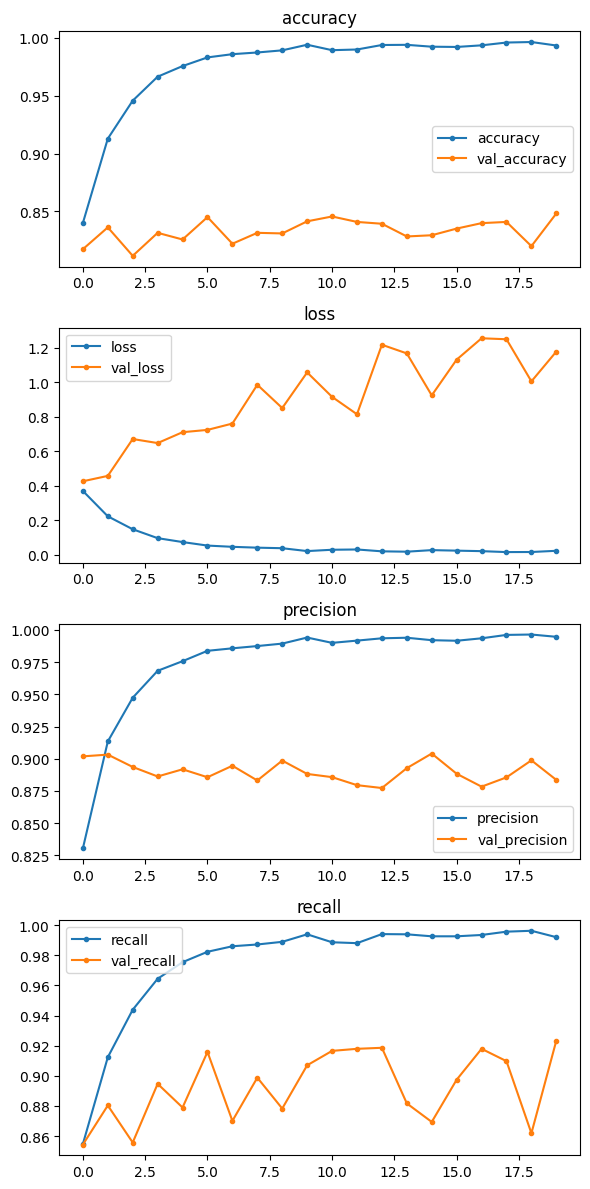

In [16]:
plot_history(history,marker='.')

426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 941us/step
----------------------------------------------------------------------
Classification metrics : Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

  not_passed       1.00      0.99      1.00      6808
      passed       0.99      1.00      1.00      6808

    accuracy                           1.00     13616
   macro avg       1.00      1.00      1.00     13616
weighted avg       1.00      1.00      1.00     13616



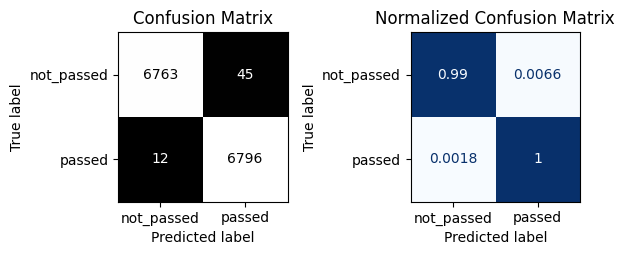


60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
----------------------------------------------------------------------
Classification metrics : Testing Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

  not_passed       0.73      0.60      0.66       461
      passed       0.88      0.93      0.90      1450

    accuracy                           0.85      1911
   macro avg       0.80      0.76      0.78      1911
weighted avg       0.84      0.85      0.84      1911



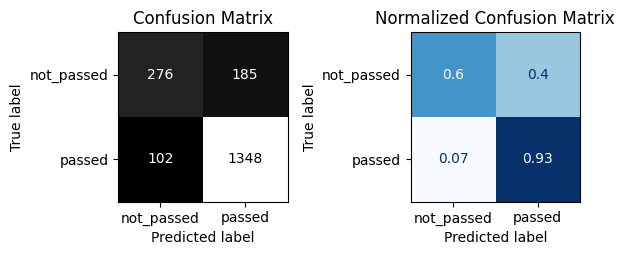

In [17]:
evaluation_classification(basic_model , X_train_smote , y_train_smote , X_test_pca , y_test , target_names = ['not_passed' , 'passed'] ,figsize = (6,4) , normalize= 'true' , output_dict = False , cmap_train = 'Blues' , cmap_test = 'Reds' , colorbar = False)

> We can see that the model is not generalizing but momerizing on the training data 
* there is over fitting and we need to do more regularization
* over fitting is so high with who not passed 
* memorized training data

### Second Iteration
* Drop Out Regularization
* Early Stopping
* because the overfitting is high and val_loss is increasing we will use early stopping with Dropout to solve overfitting
* reducing number of layers and epochs to reduce overfitting
* reduce number of neurons to reduce overfitting

In [18]:
def build_model(): 
    model = Sequential()
    model.add(Dense(167, activation='relu',input_shape=(input_shape,)))
    model.add(Dropout(0.6))
    model.add(Dense(84, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(42, activation='relu'))
    model.add(Dropout(0.4))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy' , metrics.Precision(), metrics.Recall()])
    return model

In [19]:
sec_model = build_model()
sec_model.summary()

C:\Users\zezo2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 167)            │        47,428 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 167)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 84)             │        14,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 42)             │         3,570 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            43 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,153 (254.50 KB)

 Trainable params: 65,153 (254.50 KB)

 Non-trainable params: 0 (0.00 B)

> because val_loss noisy/unstable
we will increase patience to 15

In [83]:
early_stopping = EarlyStopping(monitor='val_loss', patience=15,restore_best_weights = True) #saves LAST epoch, not BEST epoch

In [21]:
history = sec_model.fit(X_train_smote, y_train_smote, epochs=20,validation_data=(X_val_pca, y_val),callbacks=[early_stopping])

Epoch 1/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6946 - loss: 0.6387 - precision_1: 0.6948 - recall_1: 0.6942 - val_accuracy: 0.7996 - val_loss: 0.5169 - val_precision_1: 0.9029 - val_recall_1: 0.8269
Epoch 2/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8024 - loss: 0.4653 - precision_1: 0.7929 - recall_1: 0.8186 - val_accuracy: 0.8168 - val_loss: 0.4673 - val_precision_1: 0.9058 - val_recall_1: 0.8488
Epoch 3/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8258 - loss: 0.4179 - precision_1: 0.8149 - recall_1: 0.8431 - val_accuracy: 0.8200 - val_loss: 0.4555 - val_precision_1: 0.9098 - val_recall_1: 0.8488
Epoch 4/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8386 - loss: 0.3785 - precision_1: 0.8300 - recall_1: 0.8515 - val_accuracy: 0.8289 - val_loss: 0.4304 - val_precision_1: 0.9068 - val_recall_1: 0.8653
Epoch 5/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8473 - loss: 0.3608 - precision_1: 0.8375 - recall_1: 0.8618 -

(<Figure size 600x1200 with 4 Axes>,
 array([<Axes: title={'center': 'accuracy'}>,
        <Axes: title={'center': 'loss'}>,
        <Axes: title={'center': 'precision_1'}>,
        <Axes: title={'center': 'recall_1'}>], dtype=object))

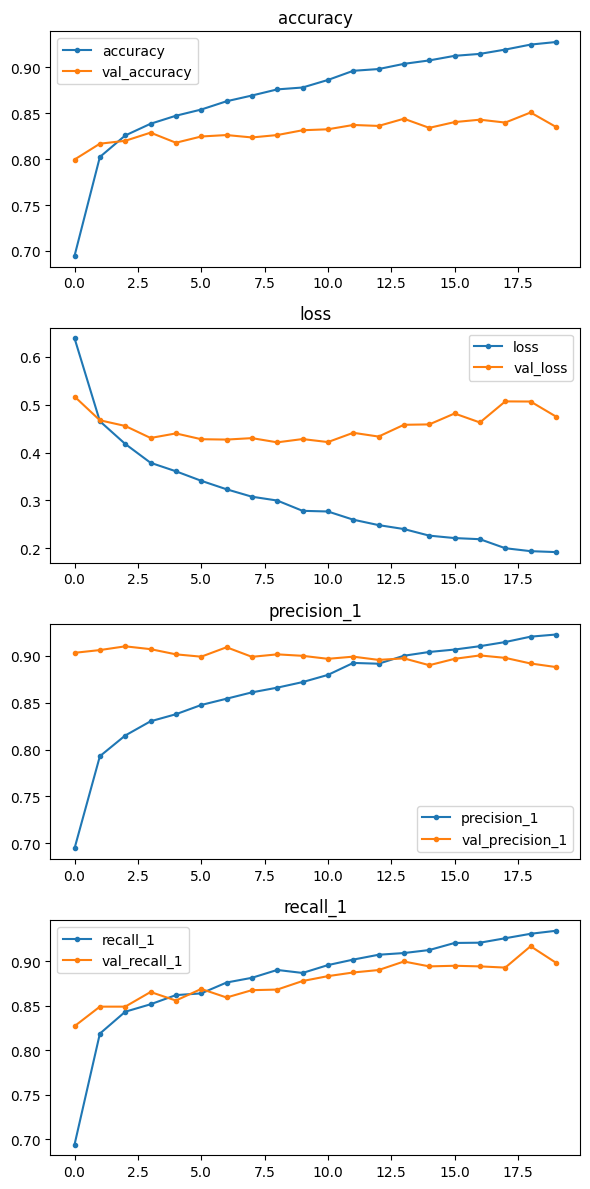

In [22]:
plot_history(history,marker='.')

426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step
----------------------------------------------------------------------
Classification metrics : Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

  not_passed       0.91      0.91      0.91      6808
      passed       0.91      0.90      0.91      6808

    accuracy                           0.91     13616
   macro avg       0.91      0.91      0.91     13616
weighted avg       0.91      0.91      0.91     13616



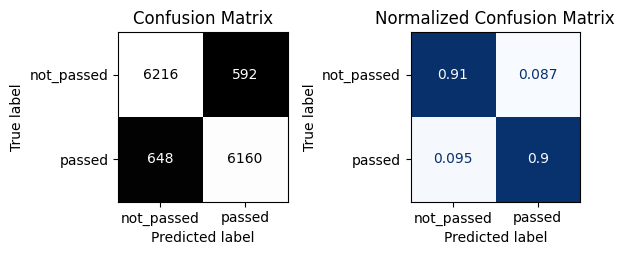


60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
----------------------------------------------------------------------
Classification metrics : Testing Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

  not_passed       0.66      0.74      0.70       461
      passed       0.91      0.88      0.90      1450

    accuracy                           0.84      1911
   macro avg       0.79      0.81      0.80      1911
weighted avg       0.85      0.84      0.85      1911



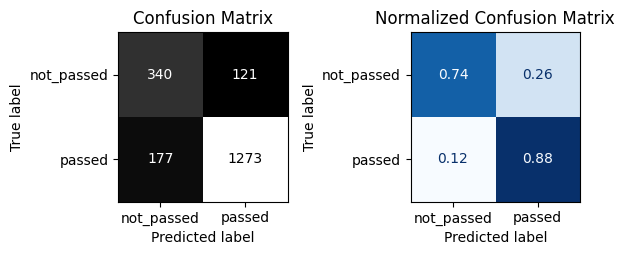

In [23]:
evaluation_classification(sec_model , X_train_smote , y_train_smote , X_test_pca , y_test , target_names = ['not_passed' , 'passed'] ,figsize = (6,4) , normalize= 'true' , output_dict = False , cmap_train = 'Blues' , cmap_test = 'Reds' , colorbar = False)

* There is still gap betwwen training and testing data , but its almost acceptable
* training data now Generalizing
* adding L1_L2 Regularization (also known as Lasso regularization) is a technique used to prevent overfitting by adding a penalty to the model's loss function based on the size of its weights.
* reducing layers and number of nurons to reduce overfitting
* increase dropout to reduce overfitting
* Batch Normalization :https://medium.com/@piyushkashyap045/understanding-batch-normalization-in-deep-learning-a-beginners-guide-40917c5bebc8

In [84]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import BatchNormalization

def build_model():
    model = Sequential()

    model.add(Dense(167, activation='relu',
                    input_shape=(input_shape,),
                    kernel_regularizer=l2(0.01)
                    ))
    model.add(BatchNormalization())  
    model.add(Dropout(0.7))

    model.add(Dense(84, activation='relu', kernel_regularizer=l2(0.01)
                    ))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(42, activation='relu', kernel_regularizer=l2(0.01)
                    ))
    model.add(BatchNormalization())
    model.add(Dropout(0.35))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(),
            tf.keras.metrics.Recall(),
            tf.keras.metrics.AUC(name='auc')
        ]
    )
    return model

In [85]:
basic_model = build_model()
basic_model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_64 (Dense)                │ (None, 167)            │        47,428 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 167)            │           668 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 167)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 84)             │        14,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 84)             │           336 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 42)             │         3,570 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 42)             │           168 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 1)              │            43 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,325 (259.08 KB)

 Trainable params: 65,739 (256.79 KB)

 Non-trainable params: 586 (2.29 KB)

In [86]:
history = basic_model.fit(X_train_smote,y_train_smote, epochs=50 # 50
                          ,validation_data=(X_val_pca, y_val),callbacks=[early_stopping])

Epoch 1/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7057 - auc: 0.7670 - loss: 3.1523 - precision_16: 0.7124 - recall_16: 0.6899 - val_accuracy: 0.7671 - val_auc: 0.8398 - val_loss: 2.0871 - val_precision_16: 0.9144 - val_recall_16: 0.7674
Epoch 2/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7975 - auc: 0.8724 - loss: 1.4766 - precision_16: 0.7918 - recall_16: 0.8073 - val_accuracy: 0.8189 - val_auc: 0.8568 - val_loss: 1.0754 - val_precision_16: 0.9073 - val_recall_16: 0.8502
Epoch 3/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8204 - auc: 0.8984 - loss: 0.8392 - precision_16: 0.8118 - recall_16: 0.8340 - val_accuracy: 0.8221 - val_auc: 0.8666 - val_loss: 0.7401 - val_precision_16: 0.9042 - val_recall_16: 0.8584
Epoch 4/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8267 - auc: 0.9042 - loss: 0.6508 - precision_16: 0.8190 - recall_16: 0.8389 - val_accuracy: 0.8148 - val_auc: 0.8687 - val_loss: 0.6416 - val_precision_16: 0.9141 - val_re

> runing the tuner it will take so much time 

(<Figure size 600x1200 with 5 Axes>,
 array([<Axes: title={'center': 'accuracy'}>,
        <Axes: title={'center': 'auc'}>, <Axes: title={'center': 'loss'}>,
        <Axes: title={'center': 'precision_16'}>,
        <Axes: title={'center': 'recall_16'}>], dtype=object))

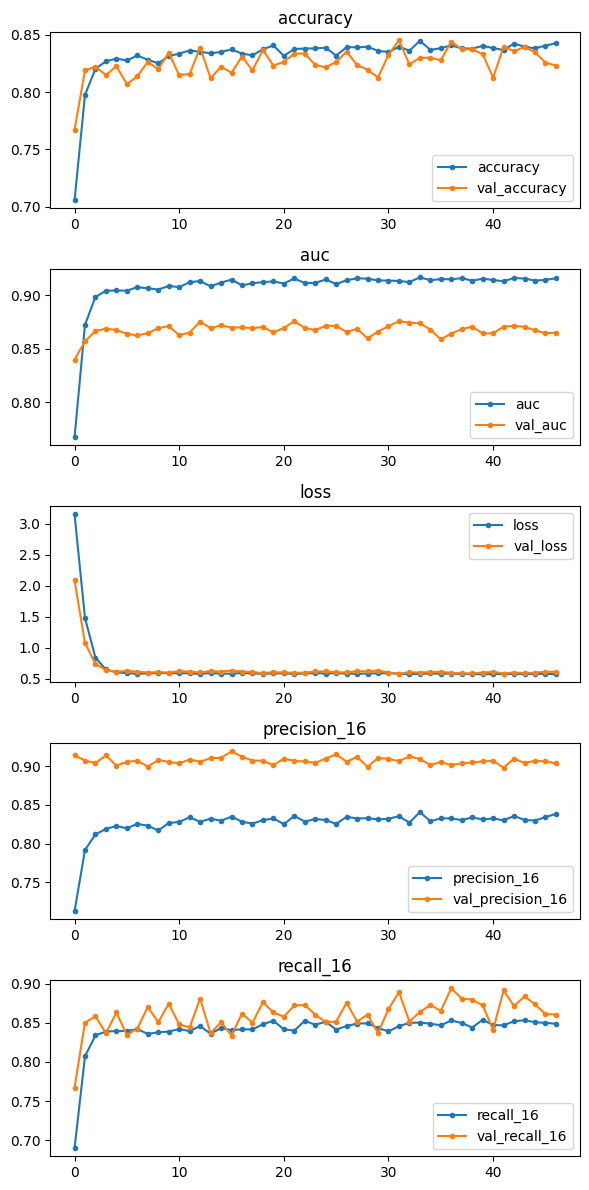

In [87]:
plot_history(history,marker='.')

426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 995us/step
----------------------------------------------------------------------
Classification metrics : Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

  not_passed       0.90      0.84      0.87      6808
      passed       0.85      0.91      0.88      6808

    accuracy                           0.88     13616
   macro avg       0.88      0.88      0.88     13616
weighted avg       0.88      0.88      0.88     13616



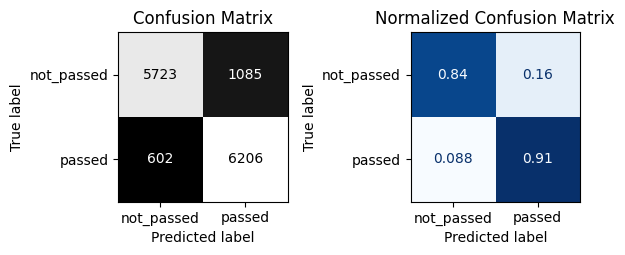


60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
----------------------------------------------------------------------
Classification metrics : Testing Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

  not_passed       0.68      0.74      0.71       461
      passed       0.92      0.89      0.90      1450

    accuracy                           0.85      1911
   macro avg       0.80      0.82      0.81      1911
weighted avg       0.86      0.85      0.86      1911



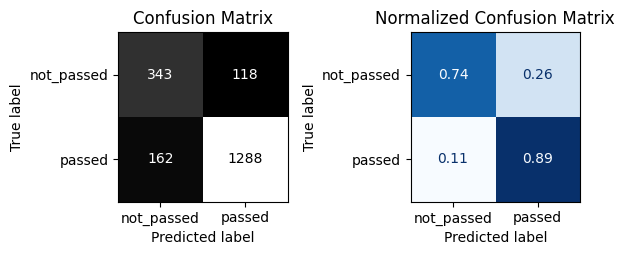

In [88]:
evaluation_classification(basic_model , X_train_smote , y_train_smote , X_test_pca , y_test , target_names = ['not_passed' , 'passed'] ,figsize = (6,4) , normalize= 'true' , output_dict = False , cmap_train = 'Blues' , cmap_test = 'Reds' , colorbar = False)

## Model Performance Analysis

---

### Overfitting Check

Comparing training and testing results reveals a **moderate overfitting** issue:

| Metric | Training | Testing | Gap |
|--------|----------|---------|-----|
| Accuracy | 0.88 | 0.85 | -0.03 |
| Passed Recall | 0.91 | 0.89 | -0.02 |
| Not Passed Precision | 0.90 | 0.68 | **-0.22** ⚠️ |

The gap is small for most metrics, but the **not_passed Precision** dropped
significantly from 0.90 to 0.68 — indicating the model struggles to
correctly identify failing cases on unseen data.

---

### Business Problem Perspective

**What the model does well:**

The model correctly identifies **89% of passed cases** (Recall = 0.89)
on the test data. This means the model is highly effective at recognizing
students or applicants who meet the passing criteria —
reducing the risk of **missing qualified candidates**.

**Where the model struggles:**

The **not_passed Precision of 0.68** means that when the model predicts
a failure, it is only correct **68% of the time**.
This results in **32% false alarms** — cases incorrectly flagged as failures.
In a business context, this could mean unnecessarily rejecting
or flagging people who would have actually passed.

---

### Recommendation

> The model is **well-suited** for identifying passing cases with high confidence.
> However, decisions based on **not_passed predictions** should be reviewed
> manually given the lower precision on that class.
>
> To improve the model further, consider:
> - Addressing the **class imbalance** in the not_passed class (support = 461 vs 1450)
> - Tuning the **decision threshold** to balance precision and recall
> - Adding more **regularization** to reduce the training/test gap 🎯